# Order Book — Construction & Matching Demo

This notebook walks through the `Order_book` class (`src/utils/order_book/order_book_impl.py`) step by step: how the book is seeded with ten levels per side, how its state can be inspected, how client orders match against market-maker orders through the matching engine, and how fills are dispatched to a registered listener. It produces the figures used in Section 1 of the written report.

**Data structure.** Two plain Python dictionaries keyed by order id (`_orders` for MM, `_client_orders` for clients) on the hot path, plus lazily-rebuilt sorted caches for price-time-priority matching. Capitalised DataFrame views (`_df_order_book`, `_df_bid_book`, `_df_ask_book`, `_df_matches`) are materialised on demand for display and analysis.

In [1]:
import importlib
import pandas as pd
import sys
sys.path.append(r'../src/')
import utils.order_book.order_book_impl as book_utils
import utils.order_book.utils as utils
import utils.order_book.graphic_utils as graph_utils

## 1. Seed ten MM levels

Post ten bids and ten asks around an EUR/USD mid of $1.10$ at a $1$ bp tick, one order per level, $1$M EUR each. We use the real public API (`post_mm_quotes`) rather than the legacy random helpers so the state of the book mirrors what the Quoter produces in the full simulation.

In [2]:
importlib.reload(book_utils)
importlib.reload(utils)
importlib.reload(graph_utils)

# FX-realistic seed: EUR/USD mid = 1.10, 1 bp tick, ten levels per side,
# 1M EUR per level. Uses the real public API (post_mm_quotes) rather than
# the legacy random helpers so the depth chart mirrors what the Quoter
# produces in the full simulation.
mid      = 1.10
tick     = 1e-4        # 1 bp
size_eur = 1_000_000
n_levels = 10

ob = book_utils.Order_book(n_levels=n_levels)

quotes = []
for lvl in range(1, n_levels + 1):
    quotes.append(book_utils.Order(
        book_utils.generate_order_id(), "buy",
        round(mid - lvl * tick, 6), size_eur, "limit_order", "market_maker", lvl,
    ))
    quotes.append(book_utils.Order(
        book_utils.generate_order_id(), "sell",
        round(mid + lvl * tick, 6), size_eur, "limit_order", "market_maker", lvl,
    ))
ob.post_mm_quotes(quotes)

best_bid = max(o["price"] for o in ob._orders.values() if o["direction"] == "buy")
best_ask = min(o["price"] for o in ob._orders.values() if o["direction"] == "sell")
print(f"Seeded {len(ob._df_order_book)} MM orders  (mid = {mid:.4f})")
print(f"  Best bid: {best_bid:.4f}   Best ask: {best_ask:.4f}   Spread: {(best_ask - best_bid) * 1e4:.1f} bp")

Seeded 20 MM orders  (mid = 1.1000)
  Best bid: 1.0999   Best ask: 1.1001   Spread: 2.0 bp


## 2. Inspect the book

Three complementary views of the same state:
- `plot_order_book` — cumulative bid/ask depth chart (exported as a report figure).
- `_df_bid_book` — raw DataFrame view of resting buy orders.
- `display_mm_quotes` — pretty ten-level ladder printed to stdout.

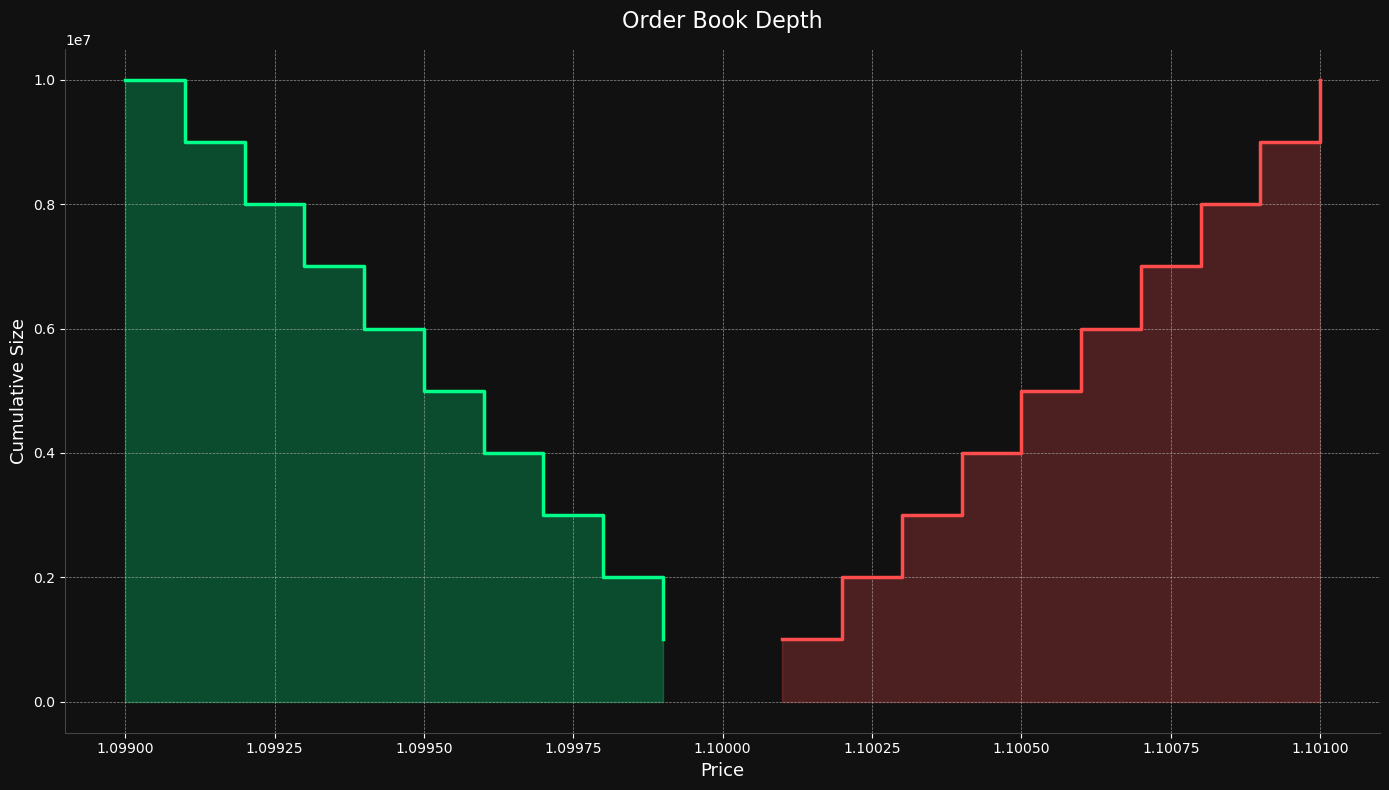

In [3]:
importlib.reload(book_utils)
importlib.reload(graph_utils)
graph_utils.plot_order_book(ob)

In [4]:
ob._df_bid_book

,Price,Size,Origin,Level
Id,,,,
1,1.0999,1000000,market_maker,1
3,1.0998,1000000,market_maker,2
5,1.0997,1000000,market_maker,3
7,1.0996,1000000,market_maker,4
9,1.0995,1000000,market_maker,5
11,1.0994,1000000,market_maker,6
13,1.0993,1000000,market_maker,7
15,1.0992,1000000,market_maker,8
17,1.0991,1000000,market_maker,9


In [5]:
# Ten-level ladder view. This is the contract the subject asks for — ten prices
# and sizes on each side — printed as a pretty text snapshot of the MM book.
ob.display_mm_quotes()

ASKS (sell)                                         
----------------------------------------------------
   Lvl         Price            Size
----------------------------------------------------
     1       1.10010      1000000.00
     2       1.10020      1000000.00
     3       1.10030      1000000.00
     4       1.10040      1000000.00
     5       1.10050      1000000.00
     6       1.10060      1000000.00
     7       1.10070      1000000.00
     8       1.10080      1000000.00
     9       1.10090      1000000.00
    10       1.10100      1000000.00
                   --- MID ---                  
     1       1.09990      1000000.00
     2       1.09980      1000000.00
     3       1.09970      1000000.00
     4       1.09960      1000000.00
     5       1.09950      1000000.00
     6       1.09940      1000000.00
     7       1.09930      1000000.00
     8       1.09920      1000000.00
     9       1.09910      1000000.00
    10       1.09900      1000000.00
---------------

## 3. Client flow & matching

With ten MM levels resting on each side, we exercise the matching engine. Client orders are drawn with prices within $\pm12$ bps of mid and sizes $200$k–$700$k EUR — a mix of marketable and non-crossing orders consistent with FX client flow.

1. **Register a listener** so fills produced by `try_clear` are captured.
2. **Build a client batch** of `Order` objects (`origin="client"`).
3. **Submit the batch** with `_add_orders_batch(orders)`.
4. **Run clearing** with `try_clear()` — matches only client-vs-MM in price-time priority, with partial fills.
5. **Inspect matches** in `ob._df_matches`.

In the full simulation, the listener is `Quoter.on_fill`, which updates inventory synchronously inside `try_clear` — no polling needed.

In [6]:
# Producer/listener demo: register a callback that prints every FillEvent
# the matching engine fires. In the full simulation, Quoter.on_fill is
# registered the same way and updates inventory synchronously inside try_clear.
fills_seen = []

def on_fill(event):
    fills_seen.append(event)
    tag = "FULL" if event.is_full_fill else "PART"
    print(f"[{tag}] MM {event.direction:>4}  lvl={event.level}  "
          f"price={event.price:.4f}  size={event.size:>7}  step={event.step}")

ob.register_quoter_listener(on_fill)
print("FillEvent listener registered.")

FillEvent listener registered.


In [7]:
import random
random.seed(42)

# Marketable client flow: each client order is submitted and cleared
# individually (route_client_order = add_order + try_clear). We price off
# the *live* top-of-book at submission time, so each order crosses
# whatever MM depth is left — no residual client orders pile up.
#
# Why this matters: Order_book.try_clear() matches client-vs-MM only,
# never client-vs-client. A non-crossing client order would sit
# untouched in the book and distort the depth chart. Keeping every
# client marketable guarantees the residual book is purely MM depth.
def submit_marketable_client(ob, tick):
    mm_bids = [o["price"] for o in ob._orders.values() if o["direction"] == "buy"]
    mm_asks = [o["price"] for o in ob._orders.values() if o["direction"] == "sell"]
    if not mm_bids or not mm_asks:
        return None
    best_bid, best_ask = max(mm_bids), min(mm_asks)
    direction      = random.choice(["buy", "sell"])
    levels_crossed = random.randint(1, 3)              # cross 1–3 MM levels
    if direction == "buy":
        price = round(best_ask + (levels_crossed - 1) * tick, 6)
    else:
        price = round(best_bid - (levels_crossed - 1) * tick, 6)
    size  = random.randint(200_000, 700_000)
    order = book_utils.Order(
        book_utils.generate_order_id(), direction, price, size,
        "limit_order", "client", 0,
    )
    ob.route_client_order(order)                       # add + try_clear
    return order

# Submit 10 client orders one by one.
for _ in range(10):
    submit_marketable_client(ob, tick)

[PART] MM sell  lvl=1  price=1.1001  size= 588786  step=0
[PART] MM  buy  lvl=1  price=1.0999  size= 317026  step=0
[PART] MM sell  lvl=1  price=1.1001  size= 253736  step=0
[FULL] MM sell  lvl=1  price=1.1001  size= 157478  step=0
[PART] MM sell  lvl=2  price=1.1002  size= 263730  step=0
[PART] MM sell  lvl=2  price=1.1002  size= 249123  step=0
[PART] MM sell  lvl=2  price=1.1002  size= 464951  step=0
[FULL] MM sell  lvl=2  price=1.1002  size=  22196  step=0
[PART] MM sell  lvl=3  price=1.1003  size= 282052  step=0
[PART] MM  buy  lvl=1  price=1.0999  size= 435514  step=0
[FULL] MM  buy  lvl=1  price=1.0999  size= 247460  step=0
[PART] MM sell  lvl=3  price=1.1003  size= 421571  step=0


In [8]:
# Resting asks after batch 1, sorted by price. Shows MM asks that were
# partially consumed (reduced size) and client asks that did not cross.
ob._df_ask_book.sort_values("Price")

,Price,Size,Origin,Level
Id,,,,
19,1.0999,350373,client,0
6,1.1003,296377,market_maker,3
8,1.1004,1000000,market_maker,4
10,1.1005,1000000,market_maker,5
12,1.1006,1000000,market_maker,6
14,1.1007,1000000,market_maker,7
16,1.1008,1000000,market_maker,8
18,1.1009,1000000,market_maker,9
20,1.1010,1000000,market_maker,10


In [9]:
# Client batch 2 — same marketable shape, priced off the live top-of-book
# (best bid/ask have shifted after batch 1 consumed shallow MM levels).
for _ in range(10):
    submit_marketable_client(ob, tick)

print(f"\nMatches so far: {len(ob._df_matches)}")
ob._df_matches[["Direction", "Price", "MatchedSize", "ClientOrderId", "MmOrderId"]]

[PART] MM  buy  lvl=2  price=1.0998  size= 281516  step=0
[PART] MM sell  lvl=3  price=1.1003  size= 253587  step=0
[FULL] MM sell  lvl=3  price=1.1003  size=  42790  step=0
[PART] MM sell  lvl=4  price=1.1004  size= 207917  step=0
[PART] MM  buy  lvl=2  price=1.0998  size= 516526  step=0
[FULL] MM  buy  lvl=2  price=1.0998  size= 201958  step=0
[PART] MM  buy  lvl=3  price=1.0997  size= 265444  step=0
[PART] MM  buy  lvl=3  price=1.0997  size= 489428  step=0
[FULL] MM  buy  lvl=3  price=1.0997  size= 245128  step=0
[PART] MM  buy  lvl=4  price=1.0996  size= 279154  step=0
[PART] MM  buy  lvl=4  price=1.0996  size= 300814  step=0
[PART] MM sell  lvl=4  price=1.1004  size= 546692  step=0

Matches so far: 24


,Direction,Price,MatchedSize,ClientOrderId,MmOrderId
0,buy,1.1001,588786,1,2
1,sell,1.0999,317026,3,1
2,buy,1.1001,253736,5,2
3,buy,1.1001,157478,7,2
4,buy,1.1002,263730,7,4
5,buy,1.1002,249123,10,4
6,buy,1.1002,464951,12,4
7,buy,1.1002,22196,14,4
8,buy,1.1003,282052,14,6
9,sell,1.0999,435514,17,1


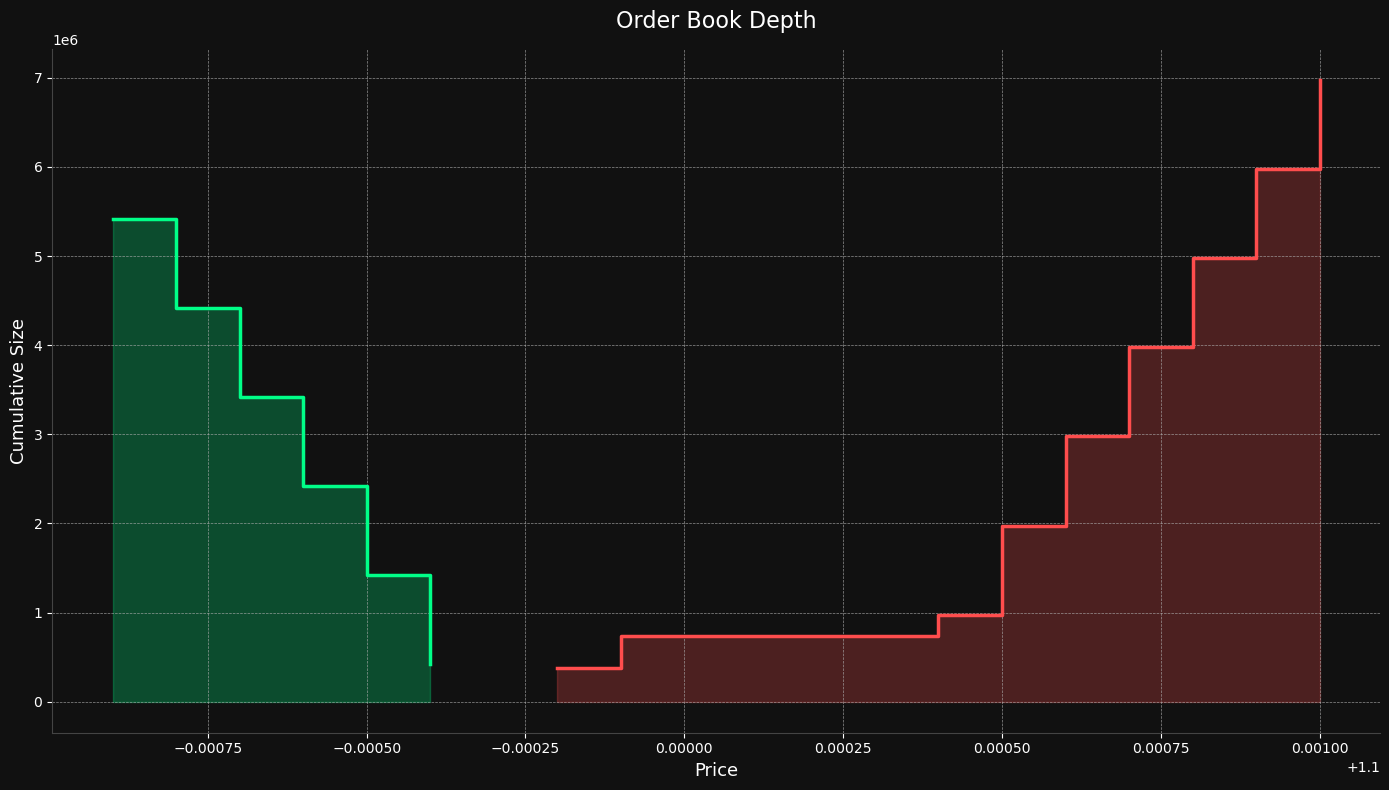

In [10]:
graph_utils.plot_order_book(ob)

In [11]:
if not ob._df_matches.empty:
    by_dir = ob._df_matches.groupby("Direction").agg(
        Matches=("MatchedSize", "count"),
        Volume=("MatchedSize", "sum"),
        AvgPrice=("Price", "mean"),
    )
    print(f"Total matched volume : {ob._df_matches['MatchedSize'].sum():,.0f}")
    print(f"Remaining open orders: {len(ob._df_order_book)}")
    print()
    print(by_dir)
else:
    print("No matches — client prices did not cross MM quotes (try re-running).")

Total matched volume : 7,334,577
Remaining open orders: 15

           Matches   Volume  AvgPrice
Direction                            
buy             13  3754609  1.100238
sell            11  3579968  1.099764


## 4. Cancel orders

Two cancellation paths: `cancel_orders(ids)` removes specific MM orders by id (used by the Quoter when stepping ladders), and `cancel_all_mm_orders()` wipes the entire MM side (used at session resets and before a full requote).

In [12]:
# cancel specific orders by ID
some_ids = ob._df_order_book.index[:3].tolist()
print(f"Before cancel_orders: {len(ob._df_order_book)} orders")
ob.cancel_orders(some_ids)
print(f"After cancel_orders({len(some_ids)} ids): {len(ob._df_order_book)} orders")

# cancel all remaining MM orders
mm_count = (ob._df_order_book["Origin"] == "market_maker").sum()
ob.cancel_all_mm_orders()
print(f"After cancel_all_mm_orders ({mm_count} removed): {len(ob._df_order_book)} orders left")
print("Remaining orders (should be client-only):")
ob._df_order_book[["Direction", "Price", "Size", "Origin"]].head(10)

Before cancel_orders: 15 orders
After cancel_orders(3 ids): 12 orders
After cancel_all_mm_orders (10 removed): 2 orders left
Remaining orders (should be client-only):


,Direction,Price,Size,Origin
Id,,,,
19,sell,1.0999,350373,client
32,sell,1.0998,380631,client
